# 93 - Code Challenge: How Big Should the Bottleneck Be?

**Section:** Autoencoders | **Prereqs:** `Autoencoders/AE_with_Tied_Weights.ipynb` | **Next:** `GANs/Linear_GANs_with_MNIST.ipynb`

A 2-D sweep - 8 latent sizes crossed with 12 encoder/decoder widths, 96
autoencoders - plotted as a heat map of reconstruction loss.

**The trade-off.** A larger bottleneck reconstructs better and compresses less.
At the extreme, a latent as wide as the input can learn the identity function and
achieve zero loss while learning nothing at all - the reconstruction loss alone
cannot tell you the code is useless.

**So do not read this map as 'lower is better'.** Read it for the *knee*: the
point where adding latent units stops buying much loss reduction. That is where
the code has captured the structure in the data, and everything past it is
memorisation capacity.

**What the code size means.** MNIST digits have roughly 10-30 real degrees of
freedom - which digit, slant, thickness, size, position. A latent much smaller
than that cannot represent a digit; much larger and the surplus units go to
copying pixels.

**If the code's usefulness is what you care about**, score it on a downstream
task instead: train a classifier on the latent and measure *its* accuracy. That
is the honest metric for a representation, and reconstruction loss is only a
proxy for it.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [16]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

In [17]:
# MNIST flattened to 784-vectors and scaled to [0,1] with MinMaxScaler.
# The [0,1] range matters: the decoder ends in sigmoid, whose range is exactly
# [0,1]. Match the output activation to the target's range.
def makeDataset():

  data_tensor = data.data.view(-1, 784)
  labels_tensor = data.targets


  from sklearn.preprocessing import MinMaxScaler

  scaler = MinMaxScaler()

  data_subset = scaler.fit_transform(data_tensor)

  train_data = torch.tensor(data_subset, dtype=torch.float, device='cuda')
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


  return train_data, train_label

In [18]:
train_data, train_label = makeDataset()

/tmp/ipython-input-289672233.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


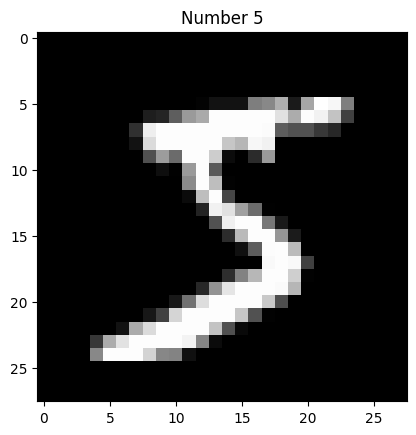

In [19]:
plt.imshow(train_data[0].reshape(28,28).detach().cpu(),cmap='gray');
plt.title(f'Number {str(train_label[0].item())}');

In [20]:
# A factory taking (latent size, encoder/decoder width), so both dimensions of
# the sweep are arguments.
# The class is defined inside the function - unusual but harmless; it just makes
# a fresh class object per call.
def make_ae(latent_no, layer_no):
  class model(nn.Module):
    def __init__(self):
      super().__init__()

      self.input_layer = nn.Linear(784, layer_no)

      self.fc1 = nn.Linear(layer_no,latent_no)

      self.fc2 = nn.Linear(latent_no,layer_no)

      self.output_layer = nn.Linear(layer_no,784)


    def forward(self,x):

      x = F.relu(self.input_layer(x))

      x = F.relu(self.fc1(x))

      x = F.relu(self.fc2(x))

      return  F.sigmoid(self.output_layer(x))

  AE = model()

  return AE

In [21]:
# One instance, to check it builds.
testAE = make_ae(100,300)

In [22]:
testAE

model(
  (input_layer): Linear(in_features=784, out_features=300, bias=True)
  (fc1): Linear(in_features=300, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=300, bias=True)
  (output_layer): Linear(in_features=300, out_features=784, bias=True)
)

In [27]:
# Note the manual batching: a random permutation each epoch, then contiguous
# slices of it. Equivalent to a shuffled DataLoader, written out by hand.
# The slice runs batchi*bs to (batchi+1)*bs - starting at (batchi-1)*bs would
# make the first iteration index -32..0, silently wrapping around to the end of
# the array.
# Only 3 epochs per model - enough to rank 96 configurations, not enough to
# train any of them properly.
def train_model(latent_no, layer_no):


  AutoEncoder = make_ae(latent_no, layer_no).to('cuda')

  epochs = 3
  lr = 0.001

  lossFunc =  nn.MSELoss()
  optimizer = torch.optim.Adam(AutoEncoder.parameters(), lr=lr)

  train_acc = []
  losses = []

  bs = 32
  noBatches = int(train_data.shape[0]/bs)


  for i in range(epochs):

    randidx = np.random.permutation(train_data.shape[0]).astype(int)

    batch_losses = []

    for batchi in range(noBatches):

      samps2use = range(batchi*bs,(batchi+1)*bs)

      X = train_data[randidx[samps2use],:]

      AutoEncoder.train()

      yhat = AutoEncoder(X)
      loss = lossFunc(yhat,X) # We compare the loss with the inital input
      batch_losses.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    losses.append(np.mean(batch_losses) )
  return np.mean(losses[-3:])

In [28]:
# One run as a smoke test before the sweep.
loss = train_model(10,10)

In [49]:
# The sweep: 8 latent sizes x 12 widths = 96 autoencoders.
# sys.stdout.write with a carriage return gives a single-line progress counter
# instead of 96 lines of output - a small thing worth stealing for long loops.
import sys

latent_numbers = np.linspace(5,100,8)
layer_numbers = np.linspace(10,500,12)

losses = np.zeros(shape=(8,12))
numcounter = 1

for ilatent, nlatent in enumerate(latent_numbers):
  for jlayer, nlayers in enumerate(layer_numbers):


   loss = train_model(int(nlatent),int(nlayers))

   losses[ilatent,jlayer] = loss

   msg = 'Finished Experiment {}/{}'.format(numcounter,96)
   numcounter += 1

   sys.stdout.write("\r"+msg)



Finished Experiment 96/96

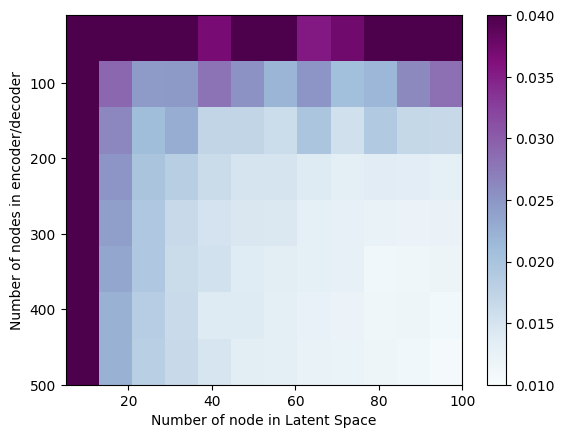

In [57]:
# The heat map of final loss.
# Do NOT simply read off the minimum. A latent as wide as the input can learn the
# identity and score near zero while learning nothing.
# Look for the KNEE: where extra latent units stop reducing loss much. That is
# where the code has captured the actual structure, and beyond it the extra
# capacity goes to copying pixels.
plt.imshow(losses, cmap='BuPu',vmax=0.04,vmin=0.01,aspect='auto',extent=[ latent_numbers[0],latent_numbers[-1],layer_numbers[-1],layer_numbers[0], ])
plt.colorbar()
plt.xlabel("Number of node in Latent Space")
plt.ylabel("Number of nodes in encoder/decoder");

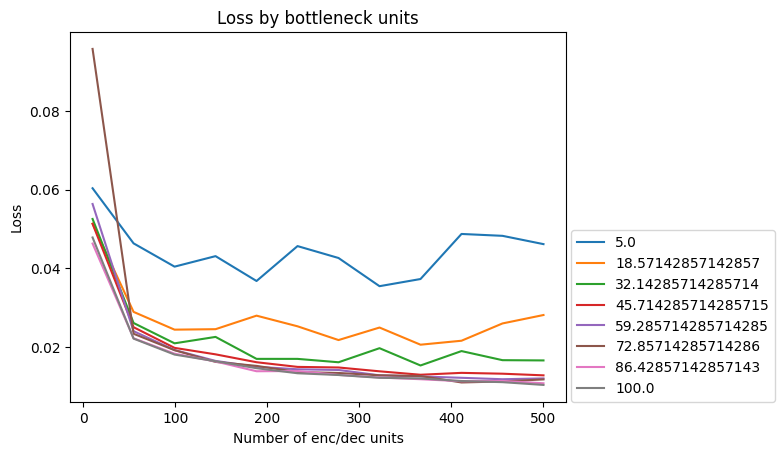

In [60]:
# The same data as line plots, one line per latent size.
# Two readings: loss falls with encoder width and flattens, and the lines for
# large latents bunch together - past a point, bottleneck size stops mattering.
# For a representation you intend to REUSE, score it on a downstream task
# instead; reconstruction loss is only a proxy for usefulness.
plt.plot(layer_numbers,losses.T)
plt.legend(latent_numbers,loc=(1.01,0))
plt.xlabel('Number of enc/dec units')
plt.title('Loss by bottleneck units')
plt.ylabel('Loss')
plt.show()
